# Singapore HDB Resale Market Analysis

## Objective

This notebook explores Singapore HDB resale transactions from 2017 onwards. It describes price distributions, transaction volumes, flat characteristics and geographical differences before the separate quality-adjusted model controls for transaction mix.

**Stakeholder:** a buyer or market analyst comparing observed market segments while avoiding causal interpretations of descriptive data.

Data source: Housing & Development Board via data.gov.sg.

## Import Libraries

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.clean_data import (
    clean_data,
    parse_remaining_lease_months,
    write_clean_outputs,
)

PRIMARY = "#0B3C5D"
ACCENT = "#E07A5F"
NEUTRAL = "#8D99AE"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
})
sgd_axis = FuncFormatter(lambda value, _: f"S${value / 1_000:,.0f}k")

## Load the Dataset

In [2]:
raw_path = PROJECT_ROOT / "data" / "raw" / "hdb_resale_raw.csv"
df = pd.read_csv(raw_path)
raw_df = df.copy()

In [3]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


## Dataset Size

In [4]:
df.shape

(239977, 11)

## Inspect the Columns

In [5]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239977 entries, 0 to 239976
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                239977 non-null  str    
 1   town                 239977 non-null  str    
 2   flat_type            239977 non-null  str    
 3   block                239977 non-null  str    
 4   street_name          239977 non-null  str    
 5   storey_range         239977 non-null  str    
 6   floor_area_sqm       239977 non-null  float64
 7   flat_model           239977 non-null  str    
 8   lease_commence_date  239977 non-null  int64  
 9   remaining_lease      239977 non-null  str    
 10  resale_price         239977 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 37.1 MB


In [7]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,239977.000000,239977.000000,2.399770e+05
mean,96.688894,1996.614763,5.347016e+05
std,24.013464,14.390192,1.921949e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.900000e+05
50%,93.000000,1997.000000,5.030000e+05
75%,112.000000,2012.000000,6.400000e+05
max,366.700000,2023.000000,1.728000e+06


## Check Missing Values

In [8]:
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [9]:
df.isnull().mean() * 100

month                  0.0
town                   0.0
flat_type              0.0
block                  0.0
street_name            0.0
storey_range           0.0
floor_area_sqm         0.0
flat_model             0.0
lease_commence_date    0.0
remaining_lease        0.0
resale_price           0.0
dtype: float64

## Check Duplicate Records

This check identifies fully identical rows only. Any duplicates found should be investigated before removal because separate transactions can legitimately share similar details. No rows are removed at this stage.

In [10]:
df.duplicated().sum()

np.int64(318)

## Explore Unique Values

In [11]:
df["town"].unique()

<ArrowStringArray>
[     'ANG MO KIO',           'BEDOK',          'BISHAN',     'BUKIT BATOK',
     'BUKIT MERAH',   'BUKIT PANJANG',     'BUKIT TIMAH',    'CENTRAL AREA',
   'CHOA CHU KANG',        'CLEMENTI',         'GEYLANG',         'HOUGANG',
     'JURONG EAST',     'JURONG WEST', 'KALLANG/WHAMPOA',   'MARINE PARADE',
       'PASIR RIS',         'PUNGGOL',      'QUEENSTOWN',       'SEMBAWANG',
        'SENGKANG',       'SERANGOON',        'TAMPINES',       'TOA PAYOH',
       'WOODLANDS',          'YISHUN']
Length: 26, dtype: str

In [12]:
df["flat_type"].unique()

<ArrowStringArray>
[          '2 ROOM',           '3 ROOM',           '4 ROOM',
           '5 ROOM',        'EXECUTIVE',           '1 ROOM',
 'MULTI-GENERATION']
Length: 7, dtype: str

In [13]:
df["flat_model"].unique()

<ArrowStringArray>
[              'Improved',         'New Generation',                   'DBSS',
               'Standard',              'Apartment',             'Simplified',
                'Model A',      'Premium Apartment',          'Adjoined flat',
     'Model A-Maisonette',             'Maisonette',                'Type S1',
                'Type S2',               'Model A2',                'Terrace',
    'Improved-Maisonette',     'Premium Maisonette',       'Multi Generation',
 'Premium Apartment Loft',                 '2-room',                   '3Gen']
Length: 21, dtype: str

In [14]:
df["storey_range"].unique()

<ArrowStringArray>
['10 TO 12', '01 TO 03', '04 TO 06', '07 TO 09', '13 TO 15', '19 TO 21',
 '22 TO 24', '16 TO 18', '34 TO 36', '28 TO 30', '37 TO 39', '49 TO 51',
 '25 TO 27', '40 TO 42', '31 TO 33', '46 TO 48', '43 TO 45']
Length: 17, dtype: str

## Data Cleaning and Feature Engineering

### Convert the Transaction Month

In [15]:
df["month"] = pd.to_datetime(df["month"])

In [16]:
df["month"].dtype

dtype('<M8[us]')

### Create Year and Month Features

In [17]:
df["year"] = df["month"].dt.year
df["month_number"] = df["month"].dt.month

In [18]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year,month_number
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017,1
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017,1
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017,1
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017,1
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017,1


### Convert Numeric Columns

In [19]:
df["resale_price"] = pd.to_numeric(
    df["resale_price"],
    errors="coerce"
)

In [20]:
df["floor_area_sqm"] = pd.to_numeric(
    df["floor_area_sqm"],
    errors="coerce"
)

### Create Price per Square Metre

Price per square metre provides a fairer comparison between flats of different sizes.

In [21]:
df["price_per_sqm"] = (
    df["resale_price"] / df["floor_area_sqm"]
)

In [22]:
df[[
    "resale_price",
    "floor_area_sqm",
    "price_per_sqm"
]].head()

,resale_price,floor_area_sqm,price_per_sqm
0,232000.0,44.0,5272.727273
1,250000.0,67.0,3731.343284
2,262000.0,67.0,3910.447761
3,265000.0,68.0,3897.058824
4,265000.0,67.0,3955.223881


### Create Approximate Flat Age

Approximate flat age at the time of sale lets us investigate whether older flats generally sell for less.

In [23]:
df["lease_commence_date"] = pd.to_numeric(
    df["lease_commence_date"],
    errors="coerce"
)

In [24]:
df["flat_age"] = (
    df["year"] - df["lease_commence_date"]
)

### Create Storey Midpoint

The midpoint converts each storey range into a numeric feature for analysing the relationship between floor level and price.

In [25]:
def get_storey_midpoint(storey_range):
    lower, upper = storey_range.split(" TO ")
    return (int(lower) + int(upper)) / 2

df["storey_mid"] = df["storey_range"].apply(
    get_storey_midpoint
)

### Convert Remaining Lease

The source text is converted to total months so lease comparisons use a validated numeric measure.

In [26]:
df["remaining_lease_months"] = df["remaining_lease"].apply(
    parse_remaining_lease_months
)

### Clean Text Columns

In [27]:
text_columns = [
    "town",
    "flat_type",
    "street_name",
    "flat_model",
    "storey_range"
]

for col in text_columns:
    df[col] = df[col].str.strip()

### Reconcile with the Shared Cleaning Pipeline

The step-by-step transformations above are retained for explanation. This check makes `src/clean_data.py` the authoritative implementation and fails if the notebook produces different values.

In [28]:
pipeline_df = clean_data(raw_df)
pd.testing.assert_frame_equal(
    df.loc[:, pipeline_df.columns].reset_index(drop=True),
    pipeline_df.reset_index(drop=True),
    check_dtype=False,
)
df = pipeline_df

### Validate the Transformations

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239977 entries, 0 to 239976
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   month                   239977 non-null  datetime64[us]
 1   town                    239977 non-null  string        
 2   flat_type               239977 non-null  string        
 3   block                   239977 non-null  str           
 4   street_name             239977 non-null  string        
 5   storey_range            239977 non-null  string        
 6   floor_area_sqm          239977 non-null  float64       
 7   flat_model              239977 non-null  string        
 8   lease_commence_date     239977 non-null  int64         
 9   remaining_lease         239977 non-null  str           
 10  resale_price            239977 non-null  float64       
 11  year                    239977 non-null  int64         
 12  month_number            239977 non-null  

In [30]:
df.isnull().sum()

month                     0
town                      0
flat_type                 0
block                     0
street_name               0
storey_range              0
floor_area_sqm            0
flat_model                0
lease_commence_date       0
remaining_lease           0
resale_price              0
year                      0
month_number              0
price_per_sqm             0
flat_age                  0
storey_mid                0
remaining_lease_months    0
dtype: int64

In [31]:
df.describe()

,month,floor_area_sqm,lease_commence_date,resale_price,year,month_number,price_per_sqm,flat_age,storey_mid,remaining_lease_months
count,239977,239977.000000,239977.000000,2.399770e+05,239977.000000,239977.000000,239977.000000,239977.000000,239977.000000,239977.000000
mean,2022-01-10 15:25:44.322998,96.688894,1996.614763,5.347016e+05,2021.571680,6.484280,5591.829534,24.956917,8.789401,889.036854
min,2017-01-01 00:00:00,31.000000,1966.000000,1.400000e+05,2017.000000,1.000000,2089.552239,1.000000,2.000000,472.000000
25%,2019-10-01 00:00:00,81.000000,1985.000000,3.900000e+05,2019.000000,4.000000,4406.779661,11.000000,5.000000,746.000000
50%,2022-02-01 00:00:00,93.000000,1997.000000,5.030000e+05,2022.000000,7.000000,5312.500000,25.000000,8.000000,886.000000
75%,2024-05-01 00:00:00,112.000000,2012.000000,6.400000e+05,2024.000000,9.000000,6351.351351,37.000000,11.000000,1063.000000
max,2026-09-01 00:00:00,366.700000,2023.000000,1.728000e+06,2026.000000,12.000000,16148.936170,60.000000,50.000000,1173.000000
std,NaN,24.013464,14.390192,1.921949e+05,2.727448,3.364016,1677.935027,14.296335,5.956696,171.926230


### Save the Clean Dataset

**Raw data → Python cleaning → Clean data**

In [32]:
clean_csv_path = PROJECT_ROOT / "data" / "processed" / "hdb_resale_clean.csv"
clean_parquet_path = PROJECT_ROOT / "data" / "processed" / "hdb_resale_clean.parquet"
metadata_path = PROJECT_ROOT / "data" / "processed" / "snapshot_metadata.json"

snapshot_metadata = write_clean_outputs(
    clean_df=df,
    raw_path=raw_path,
    clean_path=clean_csv_path,
    parquet_path=clean_parquet_path,
    metadata_path=metadata_path,
)
snapshot_metadata

{'dataset_id': 'd_8b84c4ee58e3cfc0ece0d773c8ca6abc',
 'dataset_url': 'https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view',
 'generated_at_utc': '2026-09-08T20:50:58.459888+00:00',
 'source_file': 'hdb_resale_raw.csv',
 'source_modified_at_utc': '2026-09-08T03:37:54.952169+00:00',
 'source_sha256': '69fc9ff9a87f3ecd8df7f2a606437563f3751750175e8e9eaf4bcebb81833e93',
 'processed_file': 'hdb_resale_clean.csv',
 'processed_sha256': 'ab576d05804ed2bdc8f9e156e2a95c0775a551ac22f77a77641c130803591bfb',
 'row_count': 239977,
 'column_count': 17,
 'columns': ['month',
  'town',
  'flat_type',
  'block',
  'street_name',
  'storey_range',
  'floor_area_sqm',
  'flat_model',
  'lease_commence_date',
  'remaining_lease',
  'resale_price',
  'year',
  'month_number',
  'price_per_sqm',
  'flat_age',
  'storey_mid',
  'remaining_lease_months'],
 'month_min': '2017-01',
 'month_max': '2026-09',
 'fully_identical_rows_retained': 318,
 'processed_parquet_file': 'hdb_resale_clean.parquet

# Exploratory Data Analysis

## Analytical Questions

1. How have observed HDB resale prices changed over time?
2. Which towns have the highest observed median resale prices?
3. Which towns record the most transactions?
4. How do median resale prices differ by flat type?
5. How is floor area associated with resale price?
6. How is approximate flat age associated with resale price?
7. How do observed prices differ across storey ranges?
8. Which towns show the greatest change in median transaction price?

These are descriptive questions. The quality-adjusted model evaluates the same market while holding recorded property characteristics constant.

## Overall Statistics

In [33]:
print("Total transactions:", len(df))

print(
    "Median resale price:",
    df["resale_price"].median()
)

print(
    "Average resale price:",
    df["resale_price"].mean()
)

print(
    "Median price per sqm:",
    df["price_per_sqm"].median()
)

Total transactions: 239977
Median resale price: 503000.0
Average resale price: 534701.5762763099
Median price per sqm: 5312.5


## Transactions by Year

In [34]:
transactions_by_year = (
    df.groupby("year")
      .size()
)

print(transactions_by_year)

year
2017    20509
2018    21561
2019    22186
2020    23333
2021    29087
2022    26720
2023    25754
2024    27832
2025    25085
2026    17910
dtype: int64


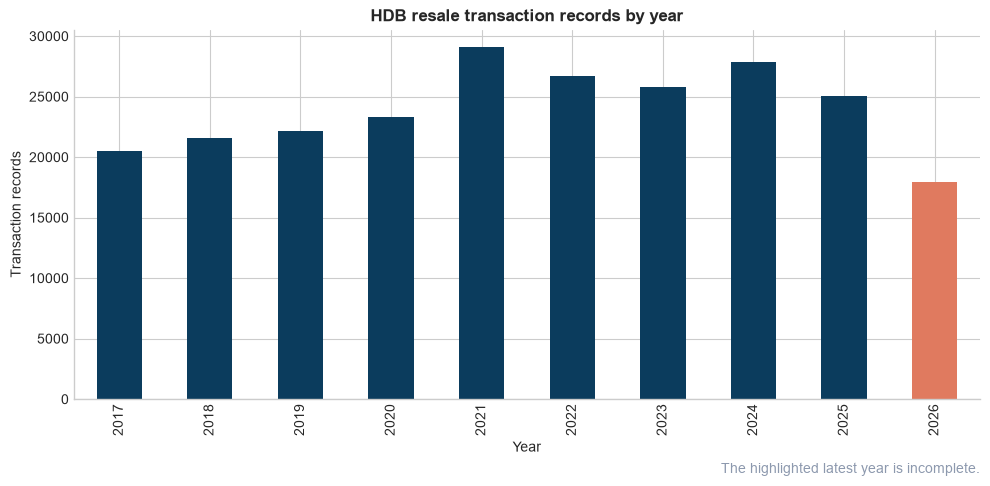

In [35]:
year_colours = [
    ACCENT if year == df["year"].max() and df.loc[df["year"].eq(year), "month_number"].nunique() < 12 else PRIMARY
    for year in transactions_by_year.index
]
axis = transactions_by_year.plot(
    kind="bar",
    figsize=(10, 5),
    color=year_colours,
)
axis.set_title("HDB resale transaction records by year")
axis.set_xlabel("Year")
axis.set_ylabel("Transaction records")
axis.text(
    1,
    -0.20,
    "The highlighted latest year is incomplete.",
    transform=axis.transAxes,
    ha="right",
    color=NEUTRAL,
)
plt.tight_layout()
plt.savefig("../images/transactions_by_year.png", dpi=170, bbox_inches="tight")
plt.show()

### Observation

Transaction volume varies across the analysed period. The latest year should be interpreted carefully because it may contain only partial-year data.

## Q1 — Median Resale Price Over Time

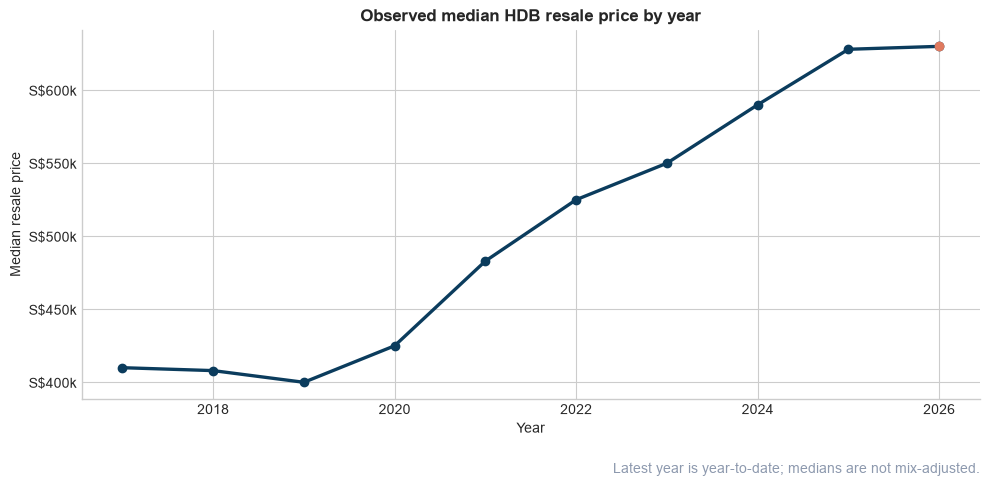

In [36]:
yearly_price = df.groupby("year")["resale_price"].median()

axis = yearly_price.plot(
    figsize=(10, 5),
    marker="o",
    linewidth=2.4,
    color=PRIMARY,
)
axis.scatter(yearly_price.index[-1], yearly_price.iloc[-1], color=ACCENT, zorder=3)
axis.set_title("Observed median HDB resale price by year")
axis.set_xlabel("Year")
axis.set_ylabel("Median resale price")
axis.yaxis.set_major_formatter(sgd_axis)
axis.text(
    1,
    -0.20,
    "Latest year is year-to-date; medians are not mix-adjusted.",
    transform=axis.transAxes,
    ha="right",
    color=NEUTRAL,
)
plt.tight_layout()
plt.savefig("../images/median_price_by_year.png", dpi=170, bbox_inches="tight")
plt.show()

## Q2 — Median Resale Price by Town

In [37]:
town_prices = (
    df.groupby("town")["resale_price"]
      .median()
      .sort_values(ascending=False)
)

print(town_prices)

town
BUKIT TIMAH        787500.0
BISHAN             700000.0
QUEENSTOWN         675000.0
BUKIT MERAH        661000.0
PASIR RIS          580000.0
CENTRAL AREA       575000.0
KALLANG/WHAMPOA    573500.0
TAMPINES           550000.0
SERANGOON          535000.0
PUNGGOL            535000.0
SENGKANG           525000.0
TOA PAYOH          515000.0
SEMBAWANG          505000.0
HOUGANG            500000.0
CLEMENTI           500000.0
CHOA CHU KANG      495000.0
MARINE PARADE      493500.0
BUKIT PANJANG      488000.0
BUKIT BATOK        485000.0
WOODLANDS          470000.0
JURONG WEST        462000.0
GEYLANG            460000.0
JURONG EAST        450000.0
BEDOK              435000.0
YISHUN             435000.0
ANG MO KIO         420000.0
Name: resale_price, dtype: float64


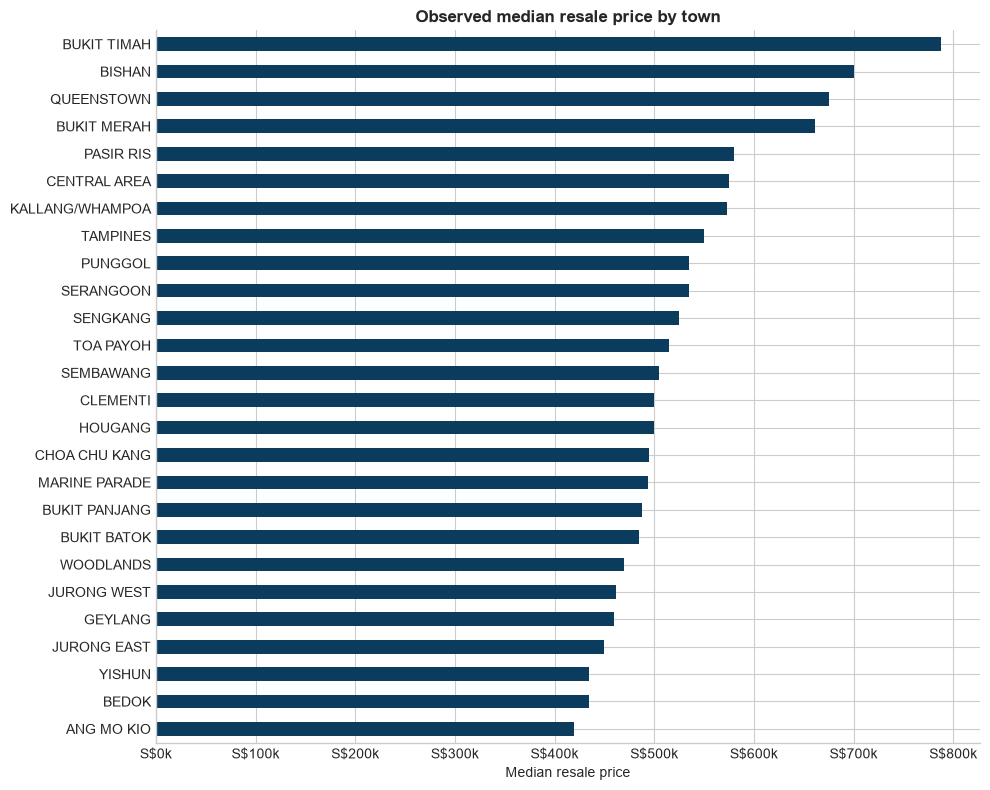

In [38]:
axis = town_prices.sort_values().plot(
    kind="barh",
    figsize=(10, 8),
    color=PRIMARY,
)
axis.set_title("Observed median resale price by town")
axis.set_xlabel("Median resale price")
axis.set_ylabel("")
axis.xaxis.set_major_formatter(sgd_axis)
plt.tight_layout()
plt.savefig("../images/median_price_by_town.png", dpi=170, bbox_inches="tight")
plt.show()

## Q3 — Transactions by Town

In [39]:
town_transactions = (
    df["town"]
      .value_counts()
)

print(town_transactions)

town
SENGKANG           19423
PUNGGOL            17371
WOODLANDS          17097
TAMPINES           16641
YISHUN             16288
JURONG WEST        15723
BEDOK              12505
HOUGANG            12116
CHOA CHU KANG      10776
BUKIT BATOK        10257
ANG MO KIO          9680
BUKIT MERAH         9131
BUKIT PANJANG       8527
TOA PAYOH           7888
SEMBAWANG           7320
KALLANG/WHAMPOA     7316
PASIR RIS           6952
QUEENSTOWN          6561
GEYLANG             5960
CLEMENTI            5301
JURONG EAST         4854
SERANGOON           4212
BISHAN              4174
CENTRAL AREA        1864
MARINE PARADE       1458
BUKIT TIMAH          582
Name: count, dtype: int64[pyarrow]


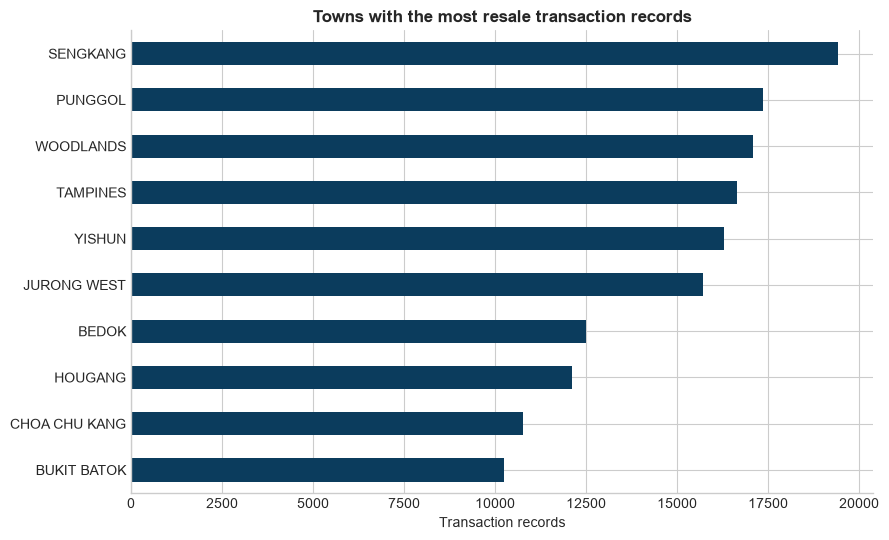

In [40]:
axis = town_transactions.head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 5.5),
    color=PRIMARY,
)
axis.set_title("Towns with the most resale transaction records")
axis.set_xlabel("Transaction records")
axis.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/top_towns_by_transactions.png", dpi=170, bbox_inches="tight")
plt.show()

## Q4 — Price by Flat Type

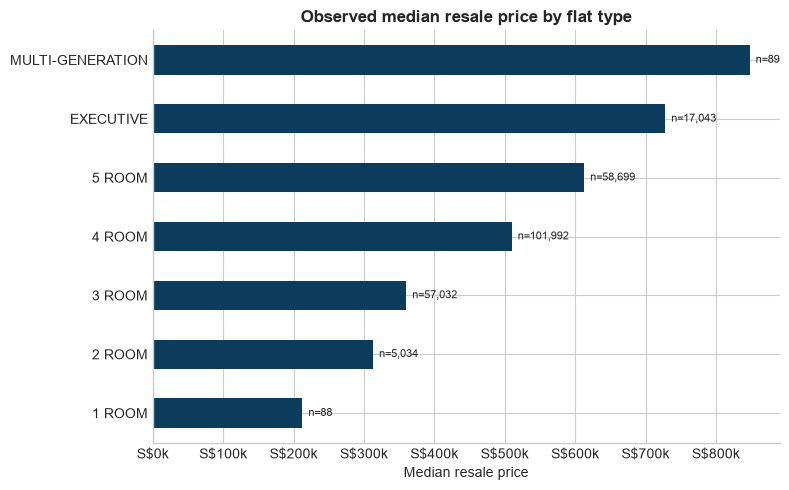

In [41]:
flat_type_summary = (
    df.groupby("flat_type")["resale_price"]
      .agg(median_price="median", transactions="size")
      .sort_values("median_price")
)
flat_type_prices = flat_type_summary["median_price"]

axis = flat_type_prices.plot(
    kind="barh",
    figsize=(8, 5),
    color=PRIMARY,
)
axis.set_title("Observed median resale price by flat type")
axis.set_xlabel("Median resale price")
axis.set_ylabel("")
axis.xaxis.set_major_formatter(sgd_axis)
for position, (_, row) in enumerate(flat_type_summary.iterrows()):
    axis.text(row["median_price"], position, f"  n={int(row['transactions']):,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../images/median_price_by_flat_type.png", dpi=170, bbox_inches="tight")
plt.show()

## Q5 — Floor Area Versus Resale Price

In [42]:
plot_df = df[[
    "floor_area_sqm",
    "flat_age",
    "resale_price",
]].dropna()

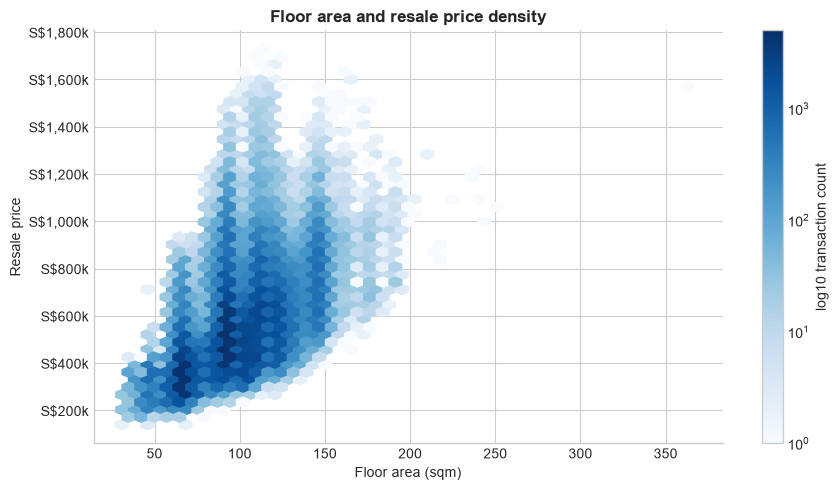

In [43]:
figure, axis = plt.subplots(figsize=(9, 5))
hexbin = axis.hexbin(
    plot_df["floor_area_sqm"],
    plot_df["resale_price"],
    gridsize=45,
    mincnt=1,
    bins="log",
    cmap="Blues",
)
figure.colorbar(hexbin, ax=axis, label="log10 transaction count")
axis.set_title("Floor area and resale price density")
axis.set_xlabel("Floor area (sqm)")
axis.set_ylabel("Resale price")
axis.yaxis.set_major_formatter(sgd_axis)
plt.tight_layout()
plt.savefig("../images/floor_area_vs_price.png", dpi=170, bbox_inches="tight")
plt.show()

## Q6 — Flat Age Versus Resale Price

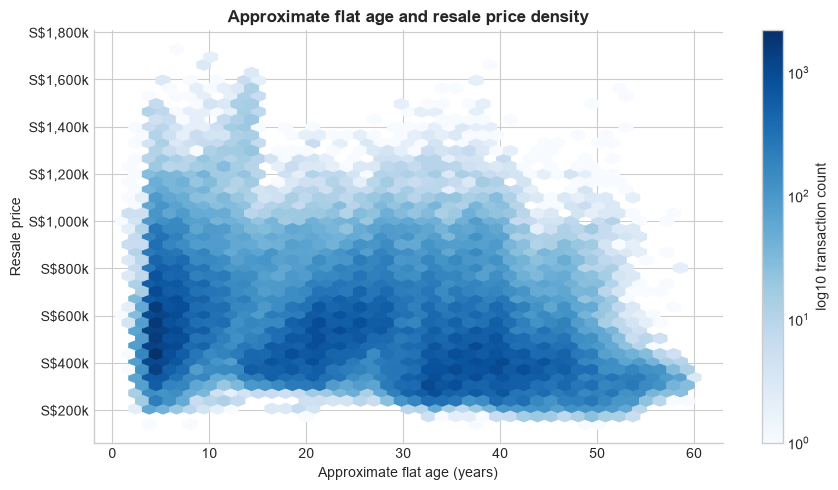

In [44]:
figure, axis = plt.subplots(figsize=(9, 5))
hexbin = axis.hexbin(
    plot_df["flat_age"],
    plot_df["resale_price"],
    gridsize=42,
    mincnt=1,
    bins="log",
    cmap="Blues",
)
figure.colorbar(hexbin, ax=axis, label="log10 transaction count")
axis.set_title("Approximate flat age and resale price density")
axis.set_xlabel("Approximate flat age (years)")
axis.set_ylabel("Resale price")
axis.yaxis.set_major_formatter(sgd_axis)
plt.tight_layout()
plt.savefig("../images/flat_age_vs_price.png", dpi=170, bbox_inches="tight")
plt.show()

## Q7 — Storey Analysis

In [45]:
storey_prices = (
    df.groupby(["storey_mid", "storey_range"], as_index=False)
      .agg(median_price=("resale_price", "median"), transactions=("resale_price", "size"))
      .sort_values("storey_mid")
)

storey_prices[["storey_range", "median_price", "transactions"]]

,storey_range,median_price,transactions
0,01 TO 03,455000.0,42116
1,04 TO 06,475000.0,55023
2,07 TO 09,490000.0,50265
3,10 TO 12,505000.0,44822
4,13 TO 15,550000.0,23194
5,16 TO 18,591750.0,10868
6,19 TO 21,680000.0,4700
7,22 TO 24,710000.0,3280
8,25 TO 27,768000.0,2047
9,28 TO 30,860000.0,1345


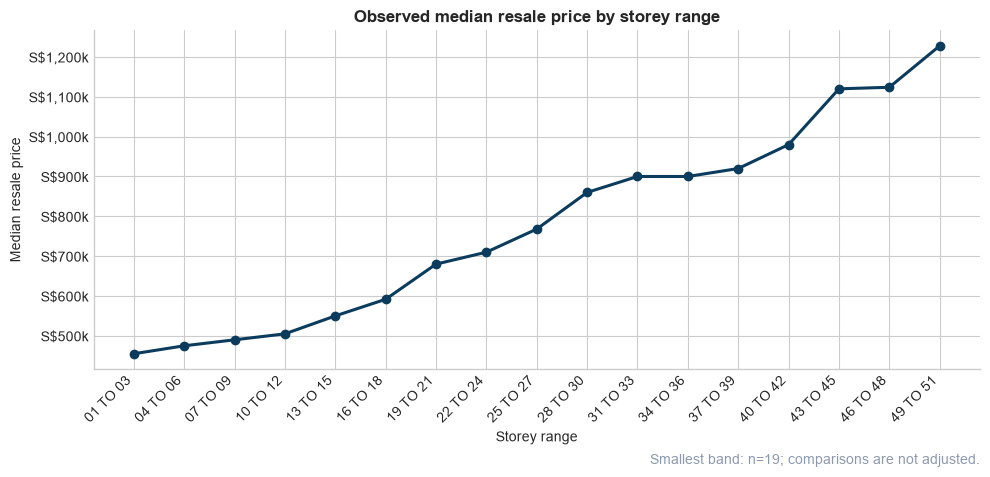

In [46]:
figure, axis = plt.subplots(figsize=(10, 5))
axis.plot(
    storey_prices["storey_mid"],
    storey_prices["median_price"],
    marker="o",
    linewidth=2.2,
    color=PRIMARY,
)
axis.set_xticks(storey_prices["storey_mid"])
axis.set_xticklabels(storey_prices["storey_range"], rotation=45, ha="right")
axis.set_title("Observed median resale price by storey range")
axis.set_xlabel("Storey range")
axis.set_ylabel("Median resale price")
axis.yaxis.set_major_formatter(sgd_axis)
axis.text(
    1,
    -0.28,
    f"Smallest band: n={storey_prices['transactions'].min():,}; comparisons are not adjusted.",
    transform=axis.transAxes,
    ha="right",
    color=NEUTRAL,
)
plt.tight_layout()
plt.savefig("../images/median_price_by_storey.png", dpi=170, bbox_inches="tight")
plt.show()

### Interpretation note

The storey comparison is descriptive. Town, flat type, floor area, age and transaction period may also influence the observed price differences.

## Q8 — Town Price Growth

The comparison uses the earliest and latest years that contain transactions in all 12 months. This prevents the partial current year from being treated as a full-year period.

In [47]:
months_by_year = df.groupby("year")["month_number"].nunique()
current_year = pd.Timestamp.today().year
complete_years = (
    months_by_year[months_by_year.eq(12) & (months_by_year.index < current_year)]
      .index
      .sort_values()
)
if len(complete_years) < 2:
    raise ValueError("At least two complete calendar years are required.")

first_complete_year = int(complete_years[0])
last_complete_year = int(complete_years[-1])
minimum_endpoint_sample = 100

town_year_summary = (
    df[df["year"].isin([first_complete_year, last_complete_year])]
      .groupby(["town", "year"])["resale_price"]
      .agg(median_price="median", transactions="size")
      .reset_index()
)
price_endpoints = town_year_summary.pivot(
    index="town", columns="year", values="median_price"
)
count_endpoints = town_year_summary.pivot(
    index="town", columns="year", values="transactions"
)
town_growth = price_endpoints[[first_complete_year, last_complete_year]].dropna().copy()
town_growth["first_year_count"] = count_endpoints[first_complete_year]
town_growth["last_year_count"] = count_endpoints[last_complete_year]
town_growth = town_growth[
    town_growth["first_year_count"].ge(minimum_endpoint_sample)
    & town_growth["last_year_count"].ge(minimum_endpoint_sample)
].copy()
town_growth["growth_pct"] = (
    (town_growth[last_complete_year] - town_growth[first_complete_year])
    / town_growth[first_complete_year]
    * 100
)
town_growth = town_growth.sort_values("growth_pct", ascending=False)
town_growth.head(10)

year,2017,2025,first_year_count,last_year_count,growth_pct
town,,,,,
TOA PAYOH,445000.0,785000.0,749,1063,76.404494
BUKIT BATOK,350000.0,600000.0,736,1304,71.428571
YISHUN,330000.0,547000.0,1257,1703,65.757576
SEMBAWANG,380000.0,620000.0,525,1191,63.157895
CHOA CHU KANG,370000.0,592888.0,804,1027,60.240000
WOODLANDS,370000.0,590000.0,1531,1748,59.459459
TAMPINES,455000.0,710000.0,1299,1921,56.043956
SENGKANG,428000.0,660888.0,1534,1905,54.413084
GEYLANG,370000.0,570000.0,567,639,54.054054


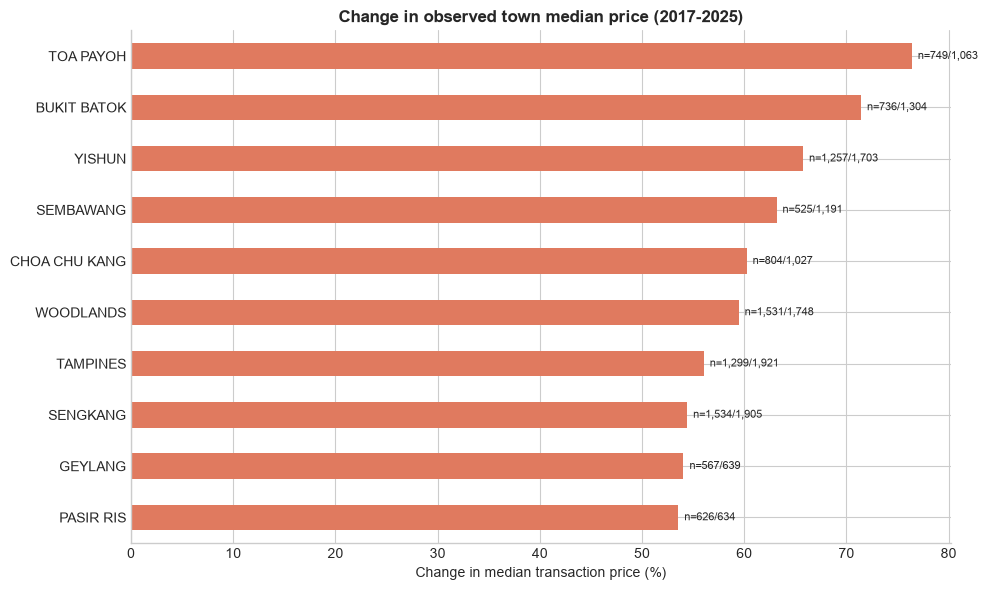

In [48]:
top_town_growth = town_growth.head(10).sort_values("growth_pct")
axis = top_town_growth["growth_pct"].plot(
    kind="barh",
    figsize=(10, 6),
    color=ACCENT,
)
axis.set_title(
    f"Change in observed town median price ({first_complete_year}-{last_complete_year})"
)
axis.set_xlabel("Change in median transaction price (%)")
axis.set_ylabel("")
for position, (_, row) in enumerate(top_town_growth.iterrows()):
    axis.text(
        row["growth_pct"],
        position,
        f"  n={int(row['first_year_count']):,}/{int(row['last_year_count']):,}",
        va="center",
        fontsize=8,
    )
plt.tight_layout()
plt.savefig("../images/town_price_growth.png", dpi=170, bbox_inches="tight")
plt.show()

### Interpretation note

Growth in the median transaction price can reflect both market movement and changes in the mix of flats sold. It is not a like-for-like property appreciation measure.

## Correlations

Correlation measures association between numerical variables; **correlation does not imply causation**.

In [49]:
correlation_columns = [
    "resale_price",
    "floor_area_sqm",
    "price_per_sqm",
    "flat_age",
    "storey_mid"
]

correlation_matrix = df[correlation_columns].corr()
correlation_matrix

,resale_price,floor_area_sqm,price_per_sqm,flat_age,storey_mid
resale_price,1.000000,0.563150,0.713222,-0.299292,0.341553
floor_area_sqm,0.563150,1.000000,-0.148072,-0.101219,-0.014420
price_per_sqm,0.713222,-0.148072,1.000000,-0.315663,0.429885
flat_age,-0.299292,-0.101219,-0.315663,1.000000,-0.273237
storey_mid,0.341553,-0.014420,0.429885,-0.273237,1.000000


# Findings and Conclusions

In [50]:
from IPython.display import Markdown, display

comparison_growth = (
    yearly_price.loc[last_complete_year]
    / yearly_price.loc[first_complete_year]
    - 1
) * 100
top_price_town = town_prices.index[0]
top_transaction_town = town_transactions.index[0]
highest_price_flat_type = flat_type_prices.idxmax()
top_growth_town = town_growth.index[0]
latest_month = df["month"].max().strftime("%B %Y")

findings = f"""
## Answers to the Eight Questions

1. **Price trend:** The annual median resale price increased from **${yearly_price.loc[first_complete_year]:,.0f}** in {first_complete_year} to **${yearly_price.loc[last_complete_year]:,.0f}** in {last_complete_year}, a **{comparison_growth:.1f}%** increase across complete years.
2. **Highest-priced town:** **{top_price_town}** has the highest overall median transaction price at **${town_prices.iloc[0]:,.0f}**.
3. **Most transactions:** **{top_transaction_town}** records the most transactions in this dataset, with **{town_transactions.iloc[0]:,.0f}** rows.
4. **Flat type:** **{highest_price_flat_type}** has the highest median transaction price at **${flat_type_prices.max():,.0f}**. Flat type comparisons also reflect differences in floor area, location and age.
5. **Floor area:** Floor area has a **{correlation_matrix.loc['resale_price', 'floor_area_sqm']:.2f}** correlation with resale price, indicating a moderate positive association in this dataset.
6. **Flat age:** Approximate flat age has a **{correlation_matrix.loc['resale_price', 'flat_age']:.2f}** correlation with resale price. The negative association does not show that age alone causes a lower price.
7. **Storey:** Storey midpoint has a **{correlation_matrix.loc['resale_price', 'storey_mid']:.2f}** correlation with resale price. Higher storey bands have higher observed medians, but the comparison is not adjusted for other property characteristics.
8. **Town growth:** **{top_growth_town}** has the largest increase in median transaction price between {first_complete_year} and {last_complete_year}, at **{town_growth.iloc[0]['growth_pct']:.1f}%**. This is not a like-for-like appreciation measure.

## Limitations

- The local snapshot runs through **{latest_month}**, so the latest year is partial and should not be compared as a full year.
- Median-price movements can reflect changes in the mix of towns, flat types, sizes, ages and storeys sold.
- The source does not include a transaction identifier or unit number. The **{int(df.duplicated().sum()):,}** fully identical rows are therefore retained rather than assumed to be errors.
- Correlation describes association and does not establish causation.
"""

display(Markdown(findings))


## Answers to the Eight Questions

1. **Price trend:** The annual median resale price increased from **$410,000** in 2017 to **$628,000** in 2025, a **53.2%** increase across complete years.
2. **Highest-priced town:** **BUKIT TIMAH** has the highest overall median transaction price at **$787,500**.
3. **Most transactions:** **SENGKANG** records the most transactions in this dataset, with **19,423** rows.
4. **Flat type:** **MULTI-GENERATION** has the highest median transaction price at **$848,000**. Flat type comparisons also reflect differences in floor area, location and age.
5. **Floor area:** Floor area has a **0.56** correlation with resale price, indicating a moderate positive association in this dataset.
6. **Flat age:** Approximate flat age has a **-0.30** correlation with resale price. The negative association does not show that age alone causes a lower price.
7. **Storey:** Storey midpoint has a **0.34** correlation with resale price. Higher storey bands have higher observed medians, but the comparison is not adjusted for other property characteristics.
8. **Town growth:** **TOA PAYOH** has the largest increase in median transaction price between 2017 and 2025, at **76.4%**. This is not a like-for-like appreciation measure.

## Limitations

- The local snapshot runs through **September 2026**, so the latest year is partial and should not be compared as a full year.
- Median-price movements can reflect changes in the mix of towns, flat types, sizes, ages and storeys sold.
- The source does not include a transaction identifier or unit number. The **318** fully identical rows are therefore retained rather than assumed to be errors.
- Correlation describes association and does not establish causation.
